Image not loaded, using a fallback blank image


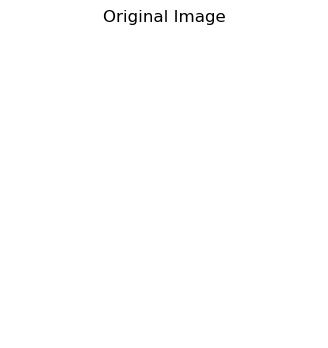

In [3]:
import cv2
import requests
import os
import matplotlib.pyplot as plt

def show_image(img, title="Image"):
    if img is None:
        print(f"Error: Image not loaded for {title}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,4))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()


# Download image (403-proof)
img_url = "https://upload.wikimedia.org/wikipedia/commons/3/3f/Fronalpstock_big.jpg"
img_path = "sample_image.jpg"

if not os.path.exists(img_path):
    headers = {'User-Agent': 'Mozilla/5.0'}
    r = requests.get(img_url, headers=headers)
    if r.status_code == 200:
        with open(img_path, 'wb') as f:
            f.write(r.content)
    else:
        print(f"Error downloading image: Status code {r.status_code}")

# Load image safely
image = cv2.imread(img_path)
if image is None:
    print("Image not loaded, using a fallback blank image")
    image = 255 * np.ones((400, 400, 3), dtype=np.uint8)  # white placeholder image

show_image(image, "Original Image")